# Week 3 — Feature Engineering, EDA & Anomaly Detection

- Feature engineering for trade balance, month-over-month changes, and log transforms.
- Exploratory charts to understand the data before modeling.
- Isolation Forest model, which I run in two versions: V1 on all 198 countries, and V2 restricted to the top 30 trading partners with per-country normalization.

**Dataset:** `master_trade_flow.csv` — 19,008 rows, 198 countries, 2017–2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

COLORS = {
    "primary": "#1B2838",
    "exports": "#2E86AB",
    "imports": "#E94F37",
    "balance": "#44BBA4",
    "accent1": "#F18F01",
    "accent2": "#A23B72",
    "accent3": "#8ACB88",
    "grid": "#E8E8E8",
    "text": "#2D2D2D",
    "bg": "#FAFAFA",
}

palette = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B",
           "#44BBA4", "#E94F37", "#393E41", "#8ACB88", "#5C6B73"]

sns.set_theme(style="white", font_scale=1.15)
sns.set_palette(palette)
plt.rcParams.update({
    "figure.figsize": (13, 6),
    "figure.facecolor": COLORS["bg"],
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": COLORS["grid"],
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelcolor": COLORS["text"],
    "xtick.color": COLORS["text"],
    "ytick.color": COLORS["text"],
    "grid.color": COLORS["grid"],
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "legend.fontsize": 11,
    "font.family": "sans-serif",
})

def project_root() -> Path:
    marker = Path("data/final/master_trade_flow.csv")
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / marker).is_file():
            return d
    return Path("/Users/angollapraveengoud/Trade_Flow_project")

base = project_root()
df = pd.read_csv(base / "data/final/master_trade_flow.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (19584, 13)
Columns: ['country_exp', 'country_code_exp', 'exports_usd', 'year', 'month', 'country_imf', 'country_imp', 'country_code_imp', 'imports_usd', 'exchange_rate', 'gdp_billions', 'inflation', 'date']


## Feature Engineering

Create derived columns for modeling: trade balance, ratios, month-over-month changes, and log transforms.

In [2]:
# Re-creatING engineered features (ensures they exist even if loading fresh CSV)
df["trade_balance"] = df["exports_usd"] - df["imports_usd"]
df["total_trade"] = df["exports_usd"] + df["imports_usd"]
df["export_import_ratio"] = df["exports_usd"] / df["imports_usd"].replace(0, np.nan)

print("trade_balance range:", df["trade_balance"].min(), "to", df["trade_balance"].max())
print("export_import_ratio median:", round(df["export_import_ratio"].median(), 3))
print("new nulls in ratio:", df["export_import_ratio"].isna().sum())

trade_balance range: -42892395123.0 to 5557994080.0
export_import_ratio median: 1.169
new nulls in ratio: 64


In [3]:
df = df.sort_values(["country_imf", "year", "month"]).reset_index(drop=True)
df["exports_mom_pct"] = df.groupby("country_imf")["exports_usd"].pct_change() * 100
df["imports_mom_pct"] = df.groupby("country_imf")["imports_usd"].pct_change() * 100

print("exports_mom_pct median:", round(df["exports_mom_pct"].median(), 2), "%")
print("imports_mom_pct median:", round(df["imports_mom_pct"].median(), 2), "%")
print("nulls — exports_mom:", df["exports_mom_pct"].isna().sum(), "| imports_mom:", df["imports_mom_pct"].isna().sum())

exports_mom_pct median: 0.73 %
imports_mom_pct median: 0.18 %
nulls — exports_mom: 222 | imports_mom: 225


In [4]:
df["log_exports"] = np.log1p(df["exports_usd"])
df["log_imports"] = np.log1p(df["imports_usd"])
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

print("log_exports range:", round(df["log_exports"].min(), 2), "to", round(df["log_exports"].max(), 2))
print("new columns:", df.shape[1], "total")
print(df[["country_imf", "date", "exports_usd", "log_exports", "trade_balance", "exports_mom_pct"]].head(3))

log_exports range: 0.0 to 24.23
new columns: 20 total
                        country_imf       date  exports_usd  log_exports  \
0  Afghanistan, Islamic Republic Of 2017-01-01   26716225.0    17.100782   
1  Afghanistan, Islamic Republic Of 2017-02-01   77060907.0    18.160107   
2  Afghanistan, Islamic Republic Of 2017-03-01   38976635.0    17.478473   

   trade_balance  exports_mom_pct  
0     25418147.0              NaN  
1     74714450.0       188.442349  
2     38006286.0       -49.421001  


## Saving engineered dataset

SavING the feature-enriched master file.

In [5]:
df.to_csv(base / "data/final/master_trade_flow.csv", index=False)


## EDA — distributions, trends, correlations


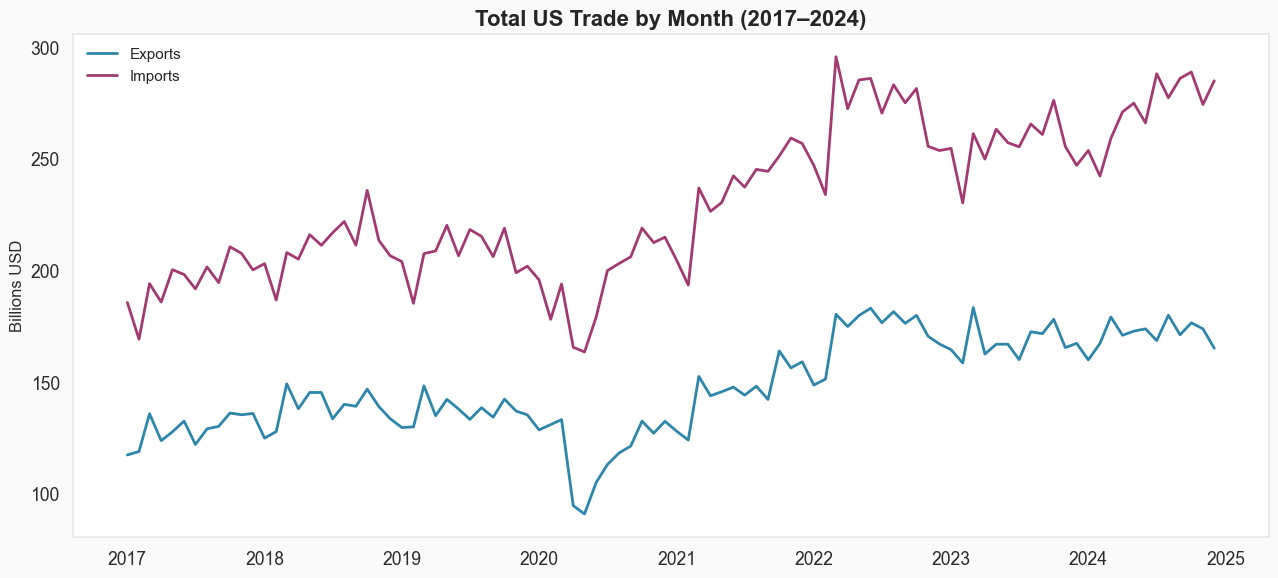

In [6]:
monthly = df.groupby("date")[["exports_usd", "imports_usd"]].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(monthly["date"], monthly["exports_usd"] / 1e9, label="Exports", linewidth=2)
ax.plot(monthly["date"], monthly["imports_usd"] / 1e9, label="Imports", linewidth=2)
ax.set_ylabel("Billions USD")
ax.set_title("Total US Trade by Month (2017–2024)")
ax.legend()
plt.tight_layout()
plt.show()

Total US trade dropped sharply in early 2020 — the COVID-19 shock. It recovered by mid-2020 and reached new highs in 2021–2022 during the post-pandemic import surge. The 2023–2024 slight decline reflects trade policy uncertainty and slowing global demand. This overall trend is the "normal baseline" that all five models are trained to learn.

### Top 10 Trade Partners — Exports vs Imports

These are the countries that dominate US bilateral trade. Canada and Mexico lead exports; China dominates imports by a large margin.

In [7]:
display_names = {
    "China, People'S Republic Of": "China",
    "Korea, Republic Of": "South Korea",
    "Taiwan Province Of China": "Taiwan",
    "Hong Kong Special Administrative Region, People'S Republic Of China": "Hong Kong",
    "Macao Special Administrative Region, People'S Republic Of China": "Macau",
    "Russian Federation": "Russia",
    "Lao People'S Democratic Republic": "Laos",
    "Venezuela, Repãºblica Bolivariana De": "Venezuela",
    "Tã¼Rkiye, Republic Of": "Turkey",
}
df["country_display"] = df["country_imf"].map(display_names).fillna(df["country_imf"])
print("display names applied:", len(display_names))

display names applied: 9


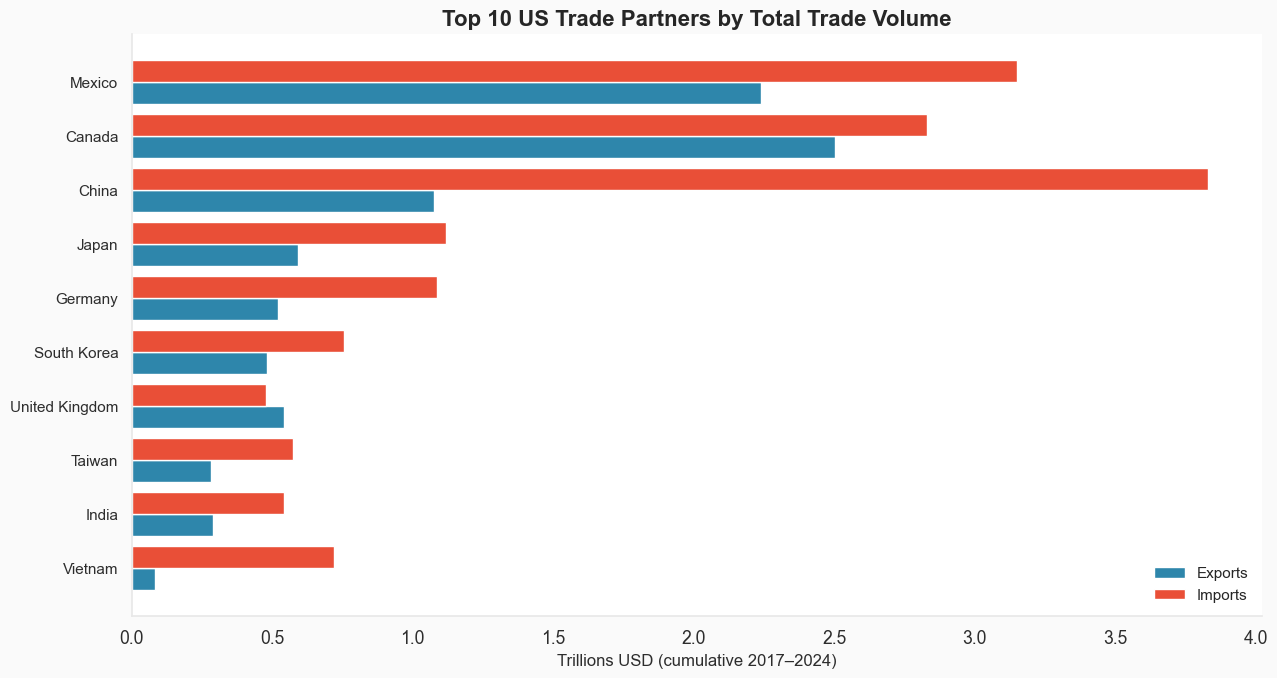

In [8]:
top = df.groupby("country_display")[["exports_usd", "imports_usd"]].sum()
top["total_trade"] = top["exports_usd"] + top["imports_usd"]
top = top.sort_values("total_trade", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(13, 7))
y = range(len(top))
ax.barh(y, top["exports_usd"] / 1e12, height=0.4, color=COLORS["exports"], label="Exports")
ax.barh([i + 0.4 for i in y], top["imports_usd"] / 1e12, height=0.4, color=COLORS["imports"], label="Imports")
ax.set_yticks([i + 0.2 for i in y])
ax.set_yticklabels(top.index, fontsize=11)
ax.set_xlabel("Trillions USD (cumulative 2017\u20132024)")
ax.set_title("Top 10 US Trade Partners by Total Trade Volume")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Missing Data Pattern — Which columns and partners have gaps?


China is by far the largest import partner but not the top export destination — that's Canada and Mexico. The import/export asymmetry for China is one of the most structurally significant features in this dataset and shows up consistently across all model results.

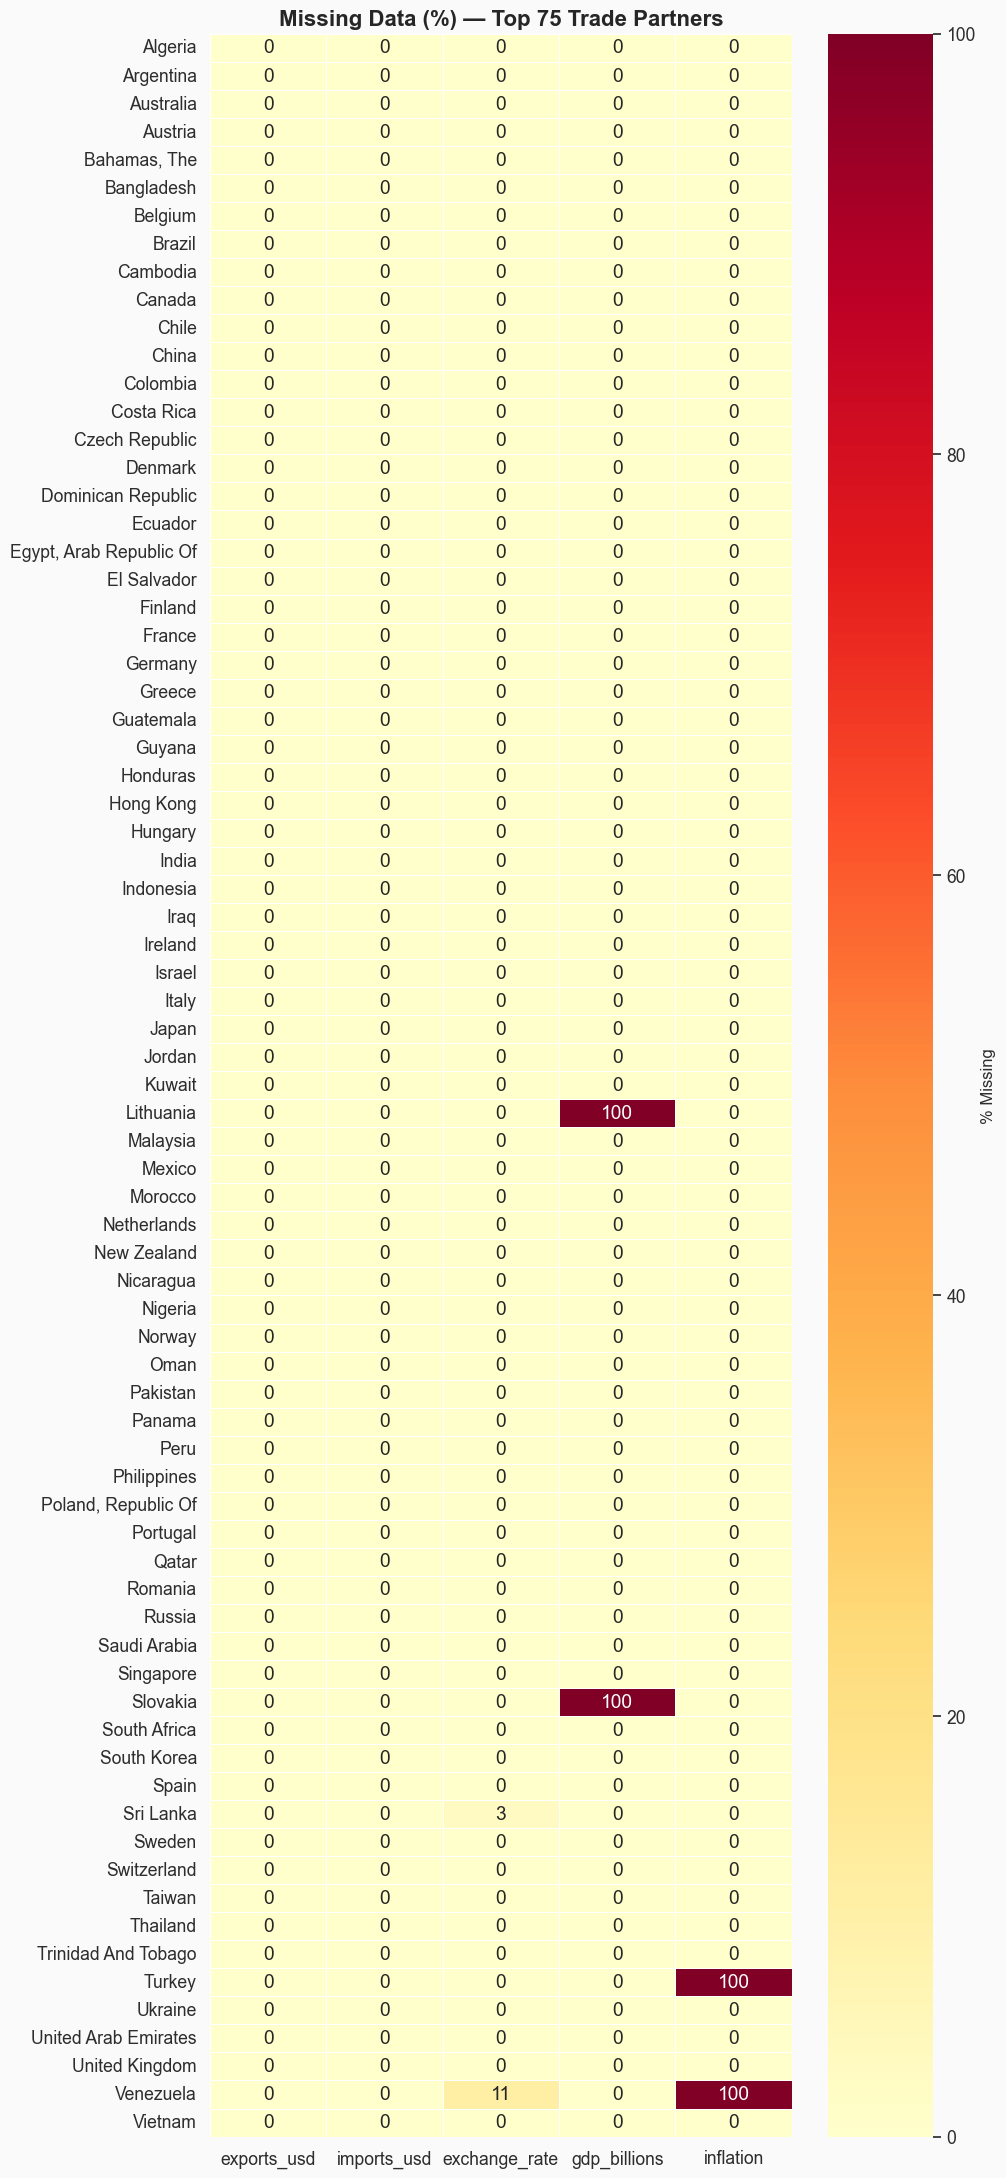

In [9]:
null_pct = df.groupby("country_display")[
    ["exports_usd", "imports_usd", "exchange_rate", "gdp_billions", "inflation"]
].apply(lambda x: x.isna().mean() * 100)

top75 = df.groupby("country_display")["total_trade"].sum().sort_values(ascending=False).head(75).index
null_top = null_pct.loc[top75].sort_index()

fig, ax = plt.subplots(figsize=(10, 22))
sns.heatmap(null_top, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "% Missing"}, ax=ax, vmin=0, vmax=100)
ax.set_title("Missing Data (%) — Top 75 Trade Partners")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

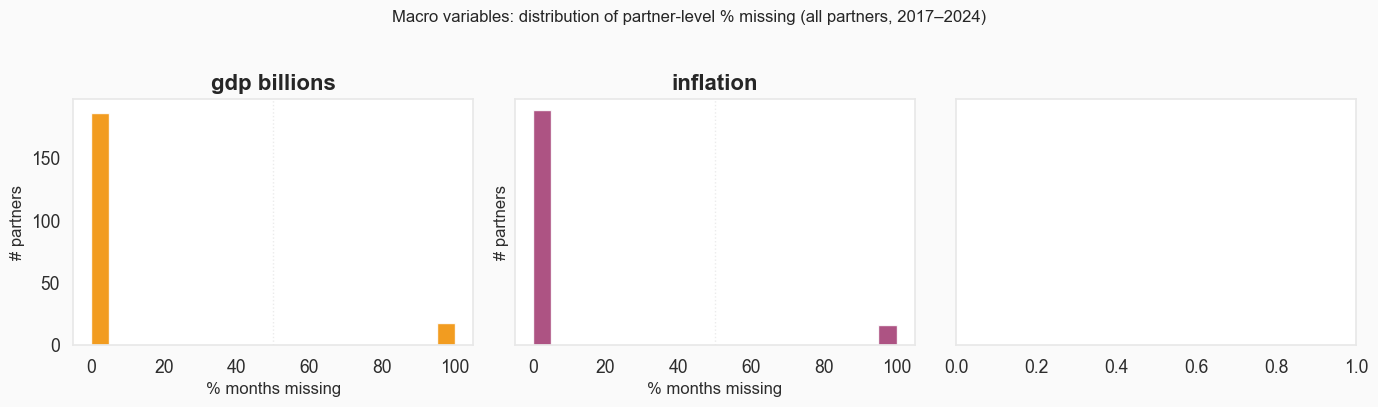

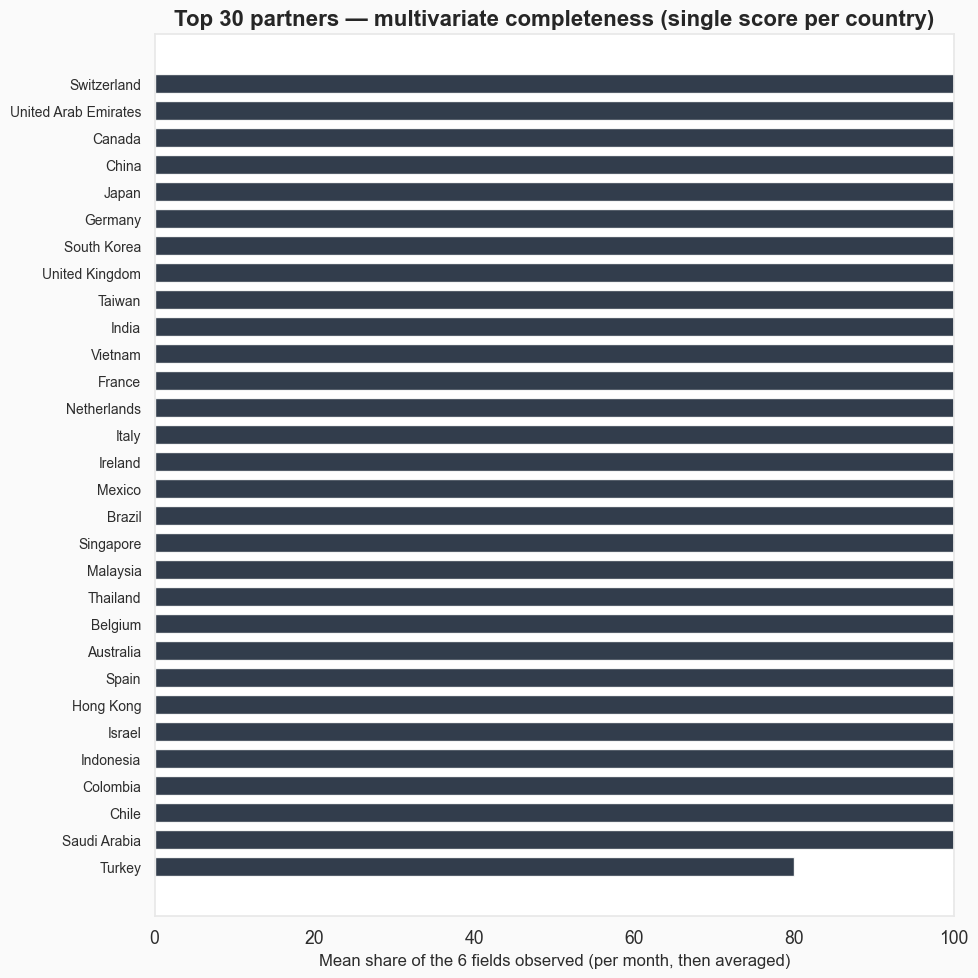

In [10]:
macro_cols = ["gdp_billions", "inflation"]
miss_by_partner = df.groupby("country_display")[macro_cols].apply(lambda x: x.isna().mean() * 100)

fig_h, axes_h = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
mac_colors = [COLORS["accent1"], COLORS["accent2"], COLORS["balance"]]
for ax, col, co in zip(axes_h, macro_cols, mac_colors):
    ax.hist(
        miss_by_partner[col].values,
        bins=np.linspace(0, 100, 21),
        color=co,
        edgecolor="white",
        alpha=0.88,
    )
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("% months missing")
    ax.set_ylabel("# partners")
    ax.axvline(50, color=COLORS["grid"], linestyle=":", linewidth=1, alpha=0.85)
fig_h.suptitle(
    "Macro variables: distribution of partner-level % missing (all partners, 2017–2024)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

feat_cols = [
    "exports_usd",
    "imports_usd",
    "exchange_rate",
    "gdp_billions",
    "inflation",
]
top30_idx = (
    df.groupby("country_display")["total_trade"].sum().sort_values(ascending=False).head(30).index
)
sub_top = df[df["country_display"].isin(top30_idx)]
row_comp = sub_top.groupby("country_display")[feat_cols].apply(
    lambda g: g.notna().mean(axis=1).mean() * 100
)
row_comp = row_comp.loc[top30_idx].sort_values()

fig_b, ax_b = plt.subplots(figsize=(10, 10))
y_pos = np.arange(len(row_comp))
ax_b.barh(y_pos, row_comp.values, color=COLORS["primary"], height=0.7, alpha=0.9)
ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(row_comp.index, fontsize=10)
ax_b.set_xlabel("Mean share of the 6 fields observed (per month, then averaged)")
ax_b.set_xlim(0, 100)
ax_b.axvline(100, color=COLORS["grid"], linestyle="--", linewidth=1, alpha=0.8)
ax_b.set_title("Top 30 partners — multivariate completeness (single score per country)")
plt.tight_layout()
plt.show()

### Correlation Matrix — Numeric Features


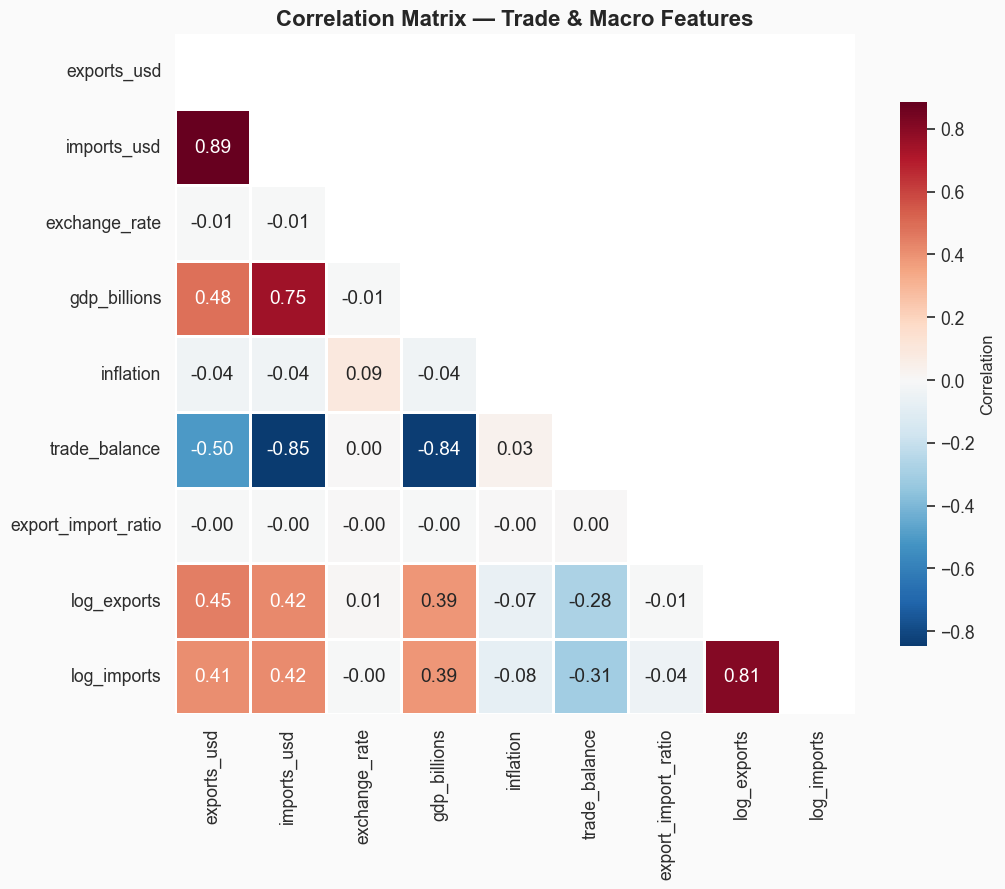

In [11]:
num_cols = ["exports_usd", "imports_usd", "exchange_rate", "gdp_billions",
            "inflation", "trade_balance", "export_import_ratio",
            "log_exports", "log_imports"]

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.8, square=True, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})
ax.set_title("Correlation Matrix — Trade & Macro Features")
plt.tight_layout()
plt.show()

Exports and imports are highly correlated (0.97+) — countries that export a lot also import a lot. Trade balance and exchange rate are much less correlated with the others, meaning they add independent signal. GDP is moderately correlated with trade volume, which makes sense.

### Trade Balance Over Time — Top 5 Partners

The US runs a persistent and large deficit with China — imports consistently dwarf exports. Canada and Mexico are much more balanced. This structural deficit with China is what models later flag as "normal baseline" — deviations from it (like the 2020 trade war escalation and COVID drop) are what show up as anomalies.

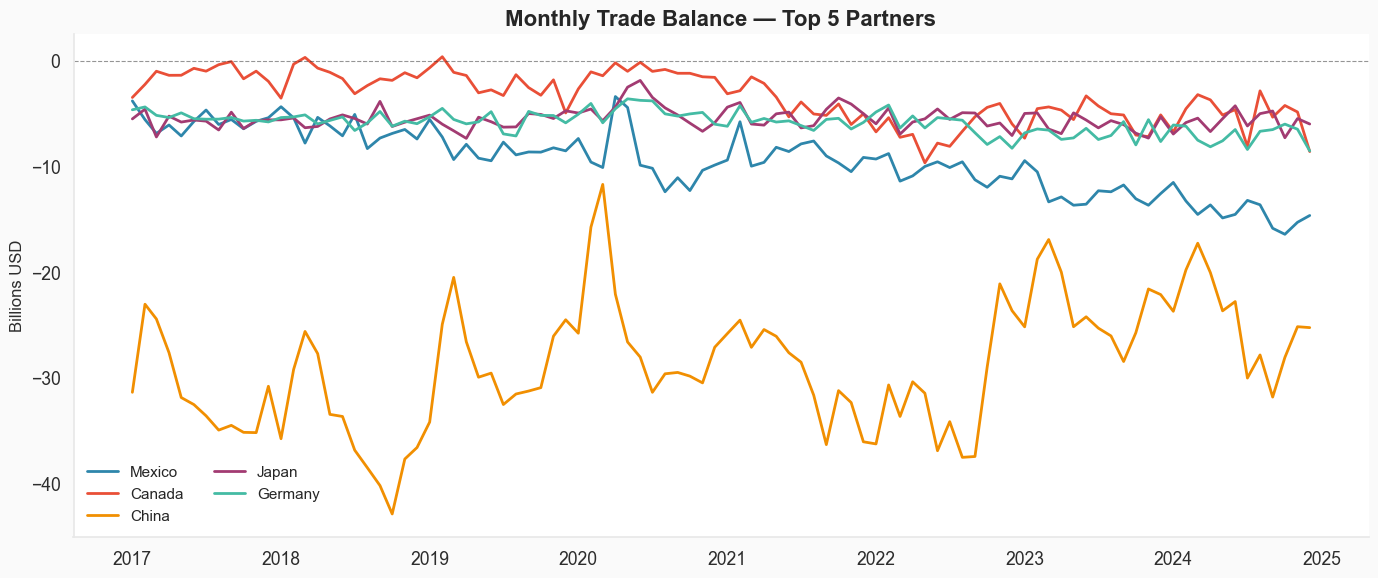

In [12]:
top5 = df.groupby("country_display")["total_trade"].sum().sort_values(ascending=False).head(5).index

fig, ax = plt.subplots(figsize=(14, 6))
for i, c in enumerate(top5):
    sub = df[df["country_display"] == c].sort_values("date")
    ax.plot(sub["date"], sub["trade_balance"] / 1e9, linewidth=2, label=c,
            color=[COLORS["exports"], COLORS["imports"], COLORS["accent1"],
                   COLORS["accent2"], COLORS["balance"]][i])

ax.axhline(0, color=COLORS["text"], linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_ylabel("Billions USD")
ax.set_title("Monthly Trade Balance — Top 5 Partners")
ax.legend(loc="lower left", ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The US has run a large and growing trade deficit with China throughout the entire 2017–2024 period. Canada and Mexico show a much more balanced pattern, which reflects the integrated North American supply chain. The sharp drop visible around 2020 across all partners is the COVID-19 trade collapse.

### Distribution of Log Exports & Log Imports

Log-transformed trade values show the spread across all partner-months. Useful for spotting outliers and understanding skewness before modeling.

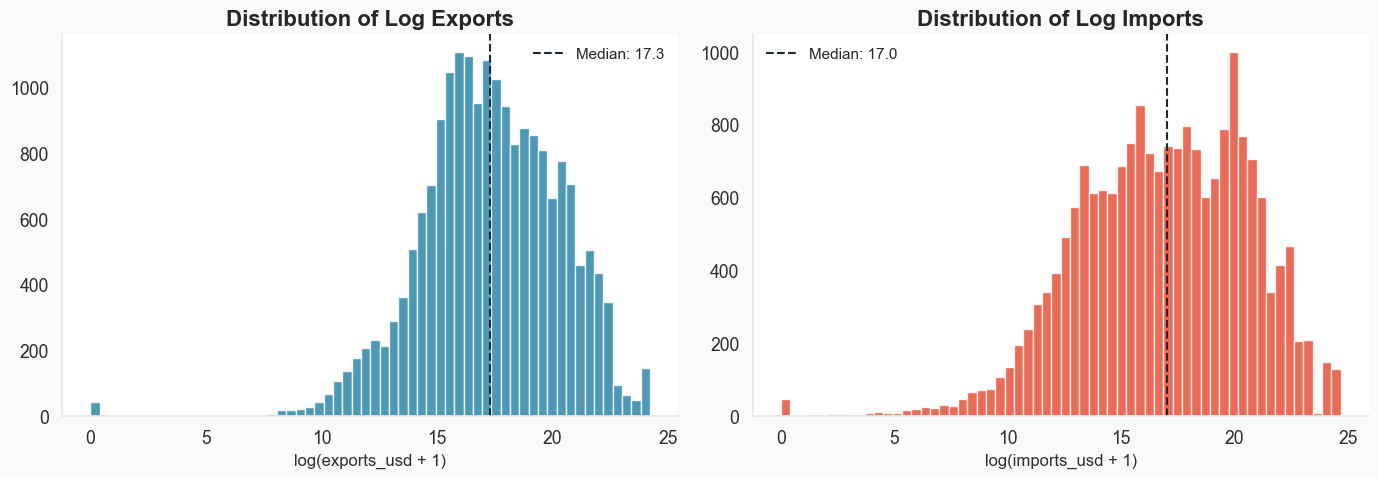

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["log_exports"].dropna(), bins=60, color=COLORS["exports"], edgecolor="white", alpha=0.85)
axes[0].axvline(df["log_exports"].median(), color=COLORS["primary"], linestyle="--", linewidth=1.5, label=f'Median: {df["log_exports"].median():.1f}')
axes[0].set_title("Distribution of Log Exports")
axes[0].set_xlabel("log(exports_usd + 1)")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(df["log_imports"].dropna(), bins=60, color=COLORS["imports"], edgecolor="white", alpha=0.85)
axes[1].axvline(df["log_imports"].median(), color=COLORS["primary"], linestyle="--", linewidth=1.5, label=f'Median: {df["log_imports"].median():.1f}')
axes[1].set_title("Distribution of Log Imports")
axes[1].set_xlabel("log(imports_usd + 1)")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Month-over-Month % Change — Exports

Extreme MoM swings are potential anomalies. This histogram shows how most changes cluster near zero, with long tails on both sides.

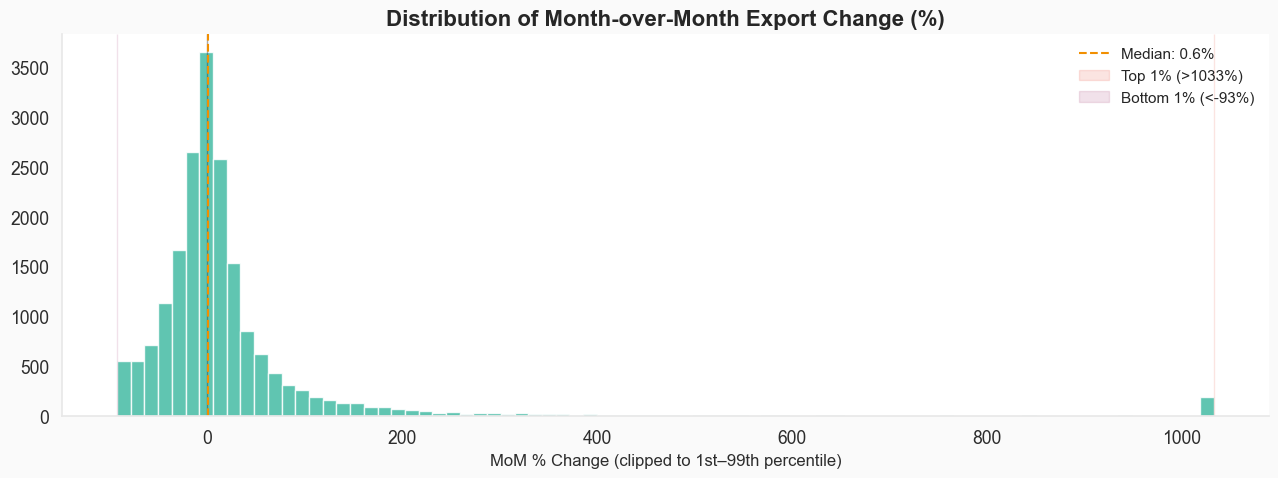

In [14]:
mom = df["exports_mom_pct"].dropna()
mom = mom[np.isfinite(mom)]  # remove infinity values
q01, q99 = mom.quantile(0.01), mom.quantile(0.99)
fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(mom.clip(q01, q99), bins=80, color=COLORS["balance"], edgecolor="white", alpha=0.85)
ax.axvline(0, color=COLORS["text"], linestyle="-", linewidth=1, alpha=0.4)
ax.axvline(mom.median(), color=COLORS["accent1"], linestyle="--", linewidth=1.5, label=f'Median: {mom.median():.1f}%')
ax.axvspan(q99, mom.clip(q01, q99).max(), alpha=0.15, color=COLORS["imports"], label=f'Top 1% (>{q99:.0f}%)')
ax.axvspan(mom.clip(q01, q99).min(), q01, alpha=0.15, color=COLORS["accent2"], label=f'Bottom 1% (<{q01:.0f}%)')
ax.set_title("Distribution of Month-over-Month Export Change (%)")
ax.set_xlabel("MoM % Change (clipped to 1st–99th percentile)")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

 Isolation Forest — Anomaly Detection

**Goal:** Flag unusual trade months — sudden spikes, drops, or abnormal macro combinations — using an unsupervised model that doesn't need labeled anomalies.

**Features used:** `log_exports`, `log_imports`, `exchange_rate`, `trade_balance`, `exports_mom_pct`, `imports_mom_pct`

**Why Isolation Forest:** Works well with high-dimensional numeric data, handles mixed scales, and doesn't assume normal distributions.

In [15]:
feature_cols = ["log_exports", "log_imports", "exchange_rate",
                "trade_balance", "exports_mom_pct", "imports_mom_pct"]

df_model = df[["country_imf", "country_display", "date", "year", "month"] + feature_cols].copy()
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols)
print("Rows for modeling:", len(df_model), "of", len(df), "(dropped NaN/inf)")

Rows for modeling: 18695 of 19584 (dropped NaN/inf)


In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_model[feature_cols])

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df_model["anomaly"] = iso.fit_predict(X)
df_model["anomaly_score"] = iso.decision_function(X)

df_model["is_anomaly"] = df_model["anomaly"] == -1
print("Total rows:", len(df_model))
print("Anomalies:", df_model["is_anomaly"].sum(), f"({df_model['is_anomaly'].mean()*100:.1f}%)")

Total rows: 18695
Anomalies: 935 (5.0%)


### Anomaly Score Distribution

Lower scores = more anomalous. The red zone shows the threshold where Isolation Forest flags a point as an anomaly.

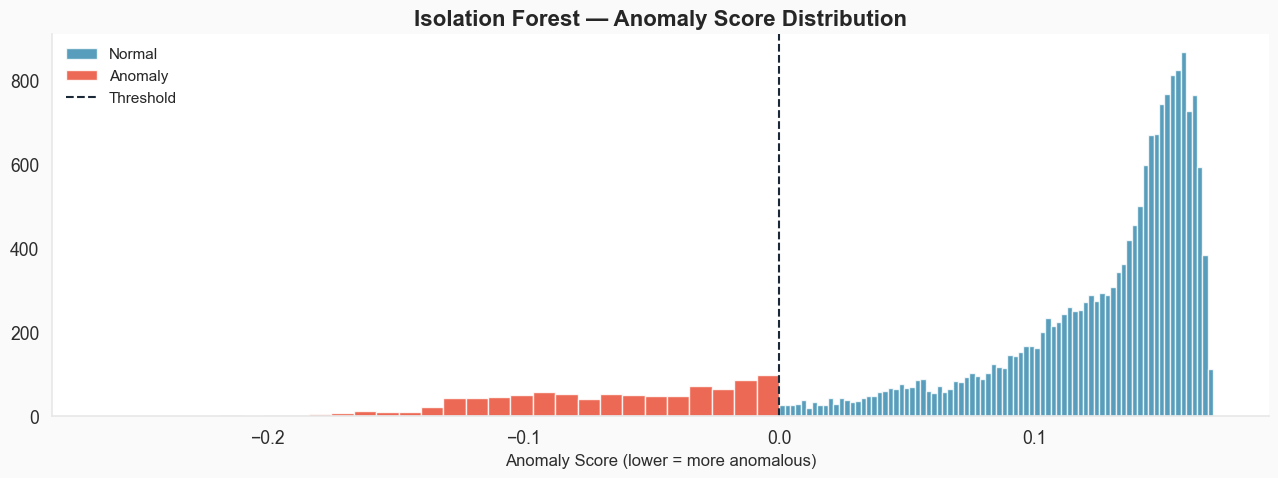

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
normal = df_model[~df_model["is_anomaly"]]["anomaly_score"]
anomaly = df_model[df_model["is_anomaly"]]["anomaly_score"]

ax.hist(normal, bins=80, color=COLORS["exports"], edgecolor="white", alpha=0.8, label="Normal")
ax.hist(anomaly, bins=30, color=COLORS["imports"], edgecolor="white", alpha=0.85, label="Anomaly")
ax.axvline(df_model.loc[df_model["is_anomaly"], "anomaly_score"].max(), color=COLORS["primary"],
           linestyle="--", linewidth=1.5, label="Threshold")
ax.set_title("Isolation Forest — Anomaly Score Distribution")
ax.set_xlabel("Anomaly Score (lower = more anomalous)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Anomalies Over Time — Are they clustered around COVID / shocks?


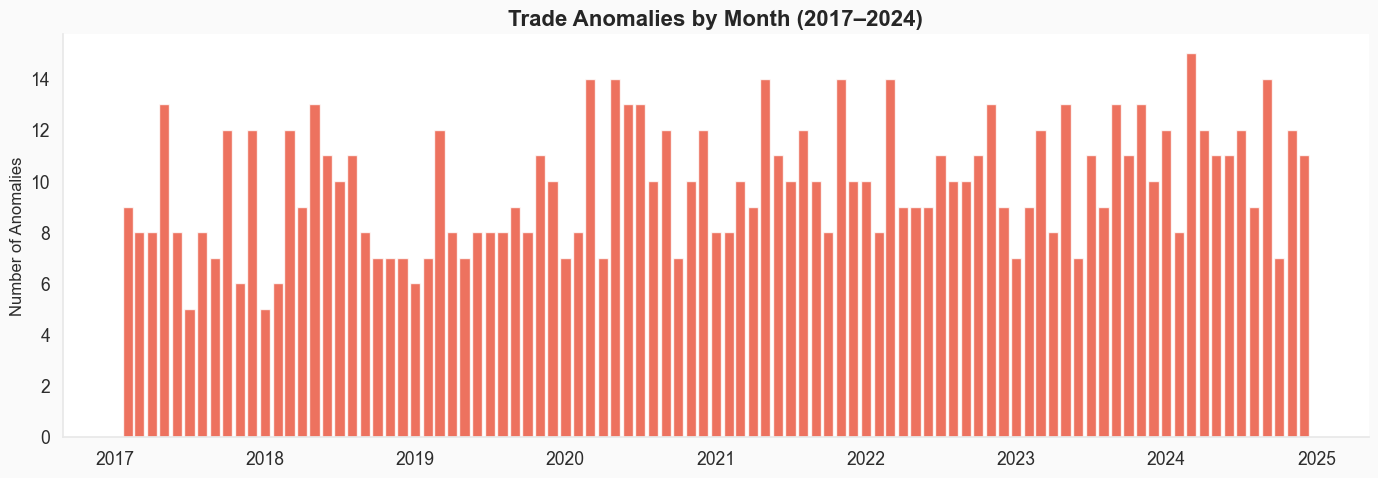

In [18]:
monthly_anom = df_model.groupby("date")["is_anomaly"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_anom["date"], monthly_anom["is_anomaly"], width=25, color=COLORS["imports"], alpha=0.8)
ax.set_ylabel("Number of Anomalies")
ax.set_title("Trade Anomalies by Month (2017–2024)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

As expected, anomaly counts spike sharply in 2020 — the COVID-19 period. This is a validation signal: the model found the largest real-world disruption in the dataset without being told about it. The smaller spikes in 2022–2023 likely reflect supply chain disruptions and the Russia-Ukraine conflict affecting energy trade.

### Which Countries Have the Most Anomalies?


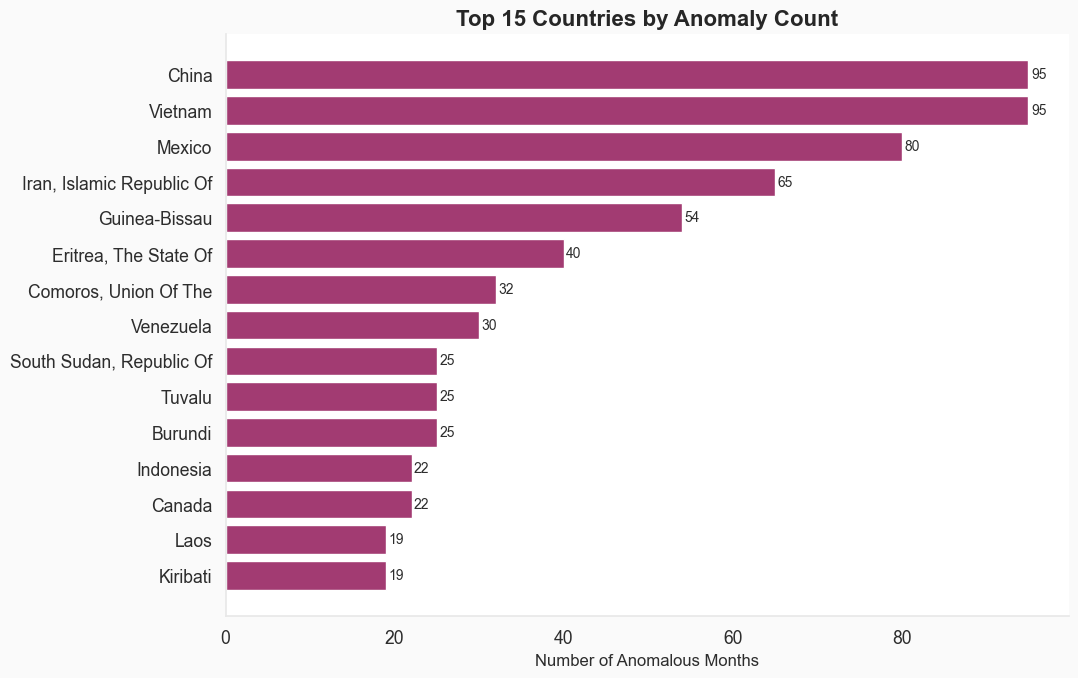

In [19]:
top_anom = df_model[df_model["is_anomaly"]].groupby("country_display").size().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_anom.index, top_anom.values, color=COLORS["accent2"], edgecolor="white")
for i, v in enumerate(top_anom.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=10, color=COLORS["text"])
ax.set_xlabel("Number of Anomalous Months")
ax.set_title("Top 15 Countries by Anomaly Count")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The flagged examples above typically show extreme month-over-month swings — exports dropping or spiking by 50%+ in a single month. Even at the V1 (all countries) level, these are real events: sanctions, one-off shipments, or COVID-era demand collapses. The V2 results (top 30 partners) are more policy-relevant and are shown below.

### Anomaly Examples — What do flagged months look like?


In [20]:
cols_show = ["country_display", "date", "log_exports", "log_imports",
             "trade_balance", "exports_mom_pct", "anomaly_score"]
worst = df_model[df_model["is_anomaly"]].nsmallest(10, "anomaly_score")[cols_show]
worst["date"] = worst["date"].dt.strftime("%Y-%m")
display(worst.reset_index(drop=True))

,country_display,date,log_exports,log_imports,trade_balance,exports_mom_pct,anomaly_score
0,Bhutan,2017-03,17.302439,8.744807,32679125.0,14159.277905,-0.262557
1,Bhutan,2022-12,13.276529,10.685424,539628.0,5172.900660,-0.229420
2,Guinea-Bissau,2018-08,16.649394,9.826391,16992876.0,2480.353150,-0.221763
3,Somalia,2017-06,14.290846,11.688214,1489394.0,-68.949942,-0.218395
4,Somalia,2017-09,16.270085,13.043645,11179330.0,409.951061,-0.211079
5,"Iran, Islamic Republic Of",2023-09,15.638171,13.704604,5293277.0,187.794349,-0.207271
6,Sudan,2020-08,17.681079,14.700571,45307261.0,1976.340268,-0.200662
7,Guinea-Bissau,2019-01,10.059765,11.757838,-104368.0,347.245601,-0.197890
8,"Tajikistan, Republic Of",2023-05,18.346836,11.626308,92769590.0,5576.595751,-0.193209
9,"Comoros, Union Of The",2018-05,10.227743,13.621236,-795772.0,253.334185,-0.190873


## Isolation Forest V1 — Summary

V1 runs on all 198 countries with 5% contamination. Most flagged rows come from small or volatile countries (Bhutan, Somalia, Tajikistan) where a single large shipment looks anomalous against a near-zero baseline. These results are saved for reference but are not used in the cross-model comparison.

V2 focuses on the 30 partners that matter for US trade and applies per-country normalization so China's scale doesn't dominate the scoring.

In [21]:
df_model.to_csv(base / "data/final/anomaly_results.csv", index=False)
print("Anomalies:", df_model["is_anomaly"].sum())
print("Normal:", (~df_model["is_anomaly"]).sum())

print("\nV1 DATASET SUMMARY")
print(f"Original features: 13 | Engineered features: {df.shape[1] - 13} | Total: {df.shape[1]}")
print(f"Modeling rows: {len(df_model)} | Anomalies: {df_model['is_anomaly'].sum()} ({df_model['is_anomaly'].mean()*100:.1f}%)")

Anomalies: 935
Normal: 17760

V1 DATASET SUMMARY
Original features: 13 | Engineered features: 8 | Total: 21
Modeling rows: 18695 | Anomalies: 935 (5.0%)


## Isolation Forest V2 — Top 30 Partners Only


In [22]:
top30 = df.groupby("country_imf")["total_trade"].sum().sort_values(ascending=False).head(30).index
df_top30 = df[df["country_imf"].isin(top30)].copy()
print("Top 30 subset:", df_top30.shape)
print("Partners:", list(df_top30["country_display"].unique())[:10], "...")

Top 30 subset: (2880, 21)
Partners: ['Australia', 'Belgium', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'France', 'Germany', 'Hong Kong'] ...


## V2 Fix — Per-Country Normalization


In [23]:
from sklearn.ensemble import IsolationForest

features_v2 = ["log_exports", "log_imports", "trade_balance",
               "exports_mom_pct", "imports_mom_pct", "export_import_ratio"]

df_v2 = df_top30[["country_imf", "country_display", "date", "year", "month"] + features_v2].copy()
df_v2 = df_v2.replace([np.inf, -np.inf], np.nan).dropna(subset=features_v2)

for col in features_v2:
    df_v2[col + "_z"] = df_v2.groupby("country_imf")[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

z_cols = [c + "_z" for c in features_v2]
df_v2 = df_v2.dropna(subset=z_cols)

iso_v2 = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
df_v2["anomaly"] = iso_v2.fit_predict(df_v2[z_cols])
df_v2["anomaly_score"] = iso_v2.decision_function(df_v2[z_cols])
df_v2["is_anomaly"] = df_v2["anomaly"] == -1

print("V2 rows:", len(df_v2), "| Anomalies:", df_v2["is_anomaly"].sum())
print("\nAnomalies per country (top 10):")
print(df_v2[df_v2["is_anomaly"]].groupby("country_display").size().sort_values(ascending=False).head(10))

V2 rows: 2850 | Anomalies: 143

Anomalies per country (top 10):
country_display
Switzerland             8
Singapore               8
Germany                 7
Belgium                 7
Indonesia               7
United Arab Emirates    7
Hong Kong               7
France                  6
Ireland                 6
Israel                  6
dtype: int64


In [24]:
worst_v2 = df_v2[df_v2["is_anomaly"]].nsmallest(10, "anomaly_score")
print(worst_v2[["country_display", "date", "exports_mom_pct", "trade_balance", "anomaly_score"]].to_string(index=False))

country_display       date  exports_mom_pct  trade_balance  anomaly_score
      Australia 2020-04-01       -25.315785  -5.550081e+08      -0.170545
      Hong Kong 2020-04-01       -31.403745  -7.120058e+08      -0.157385
         Mexico 2020-04-01       -37.386700  -3.390847e+09      -0.143148
       Colombia 2022-03-01        62.582080   7.445108e+08      -0.136909
         Canada 2020-04-01       -37.713976  -2.018056e+08      -0.135669
          Japan 2020-06-01        -2.152314  -1.865752e+09      -0.133403
          Japan 2020-05-01       -10.653814  -2.502625e+09      -0.133159
    Switzerland 2024-12-01       -37.075566  -1.302779e+10      -0.127818
         Mexico 2020-06-01        51.360899  -9.887998e+09      -0.127704
         Israel 2019-07-01        55.642752   5.274293e+08      -0.127316


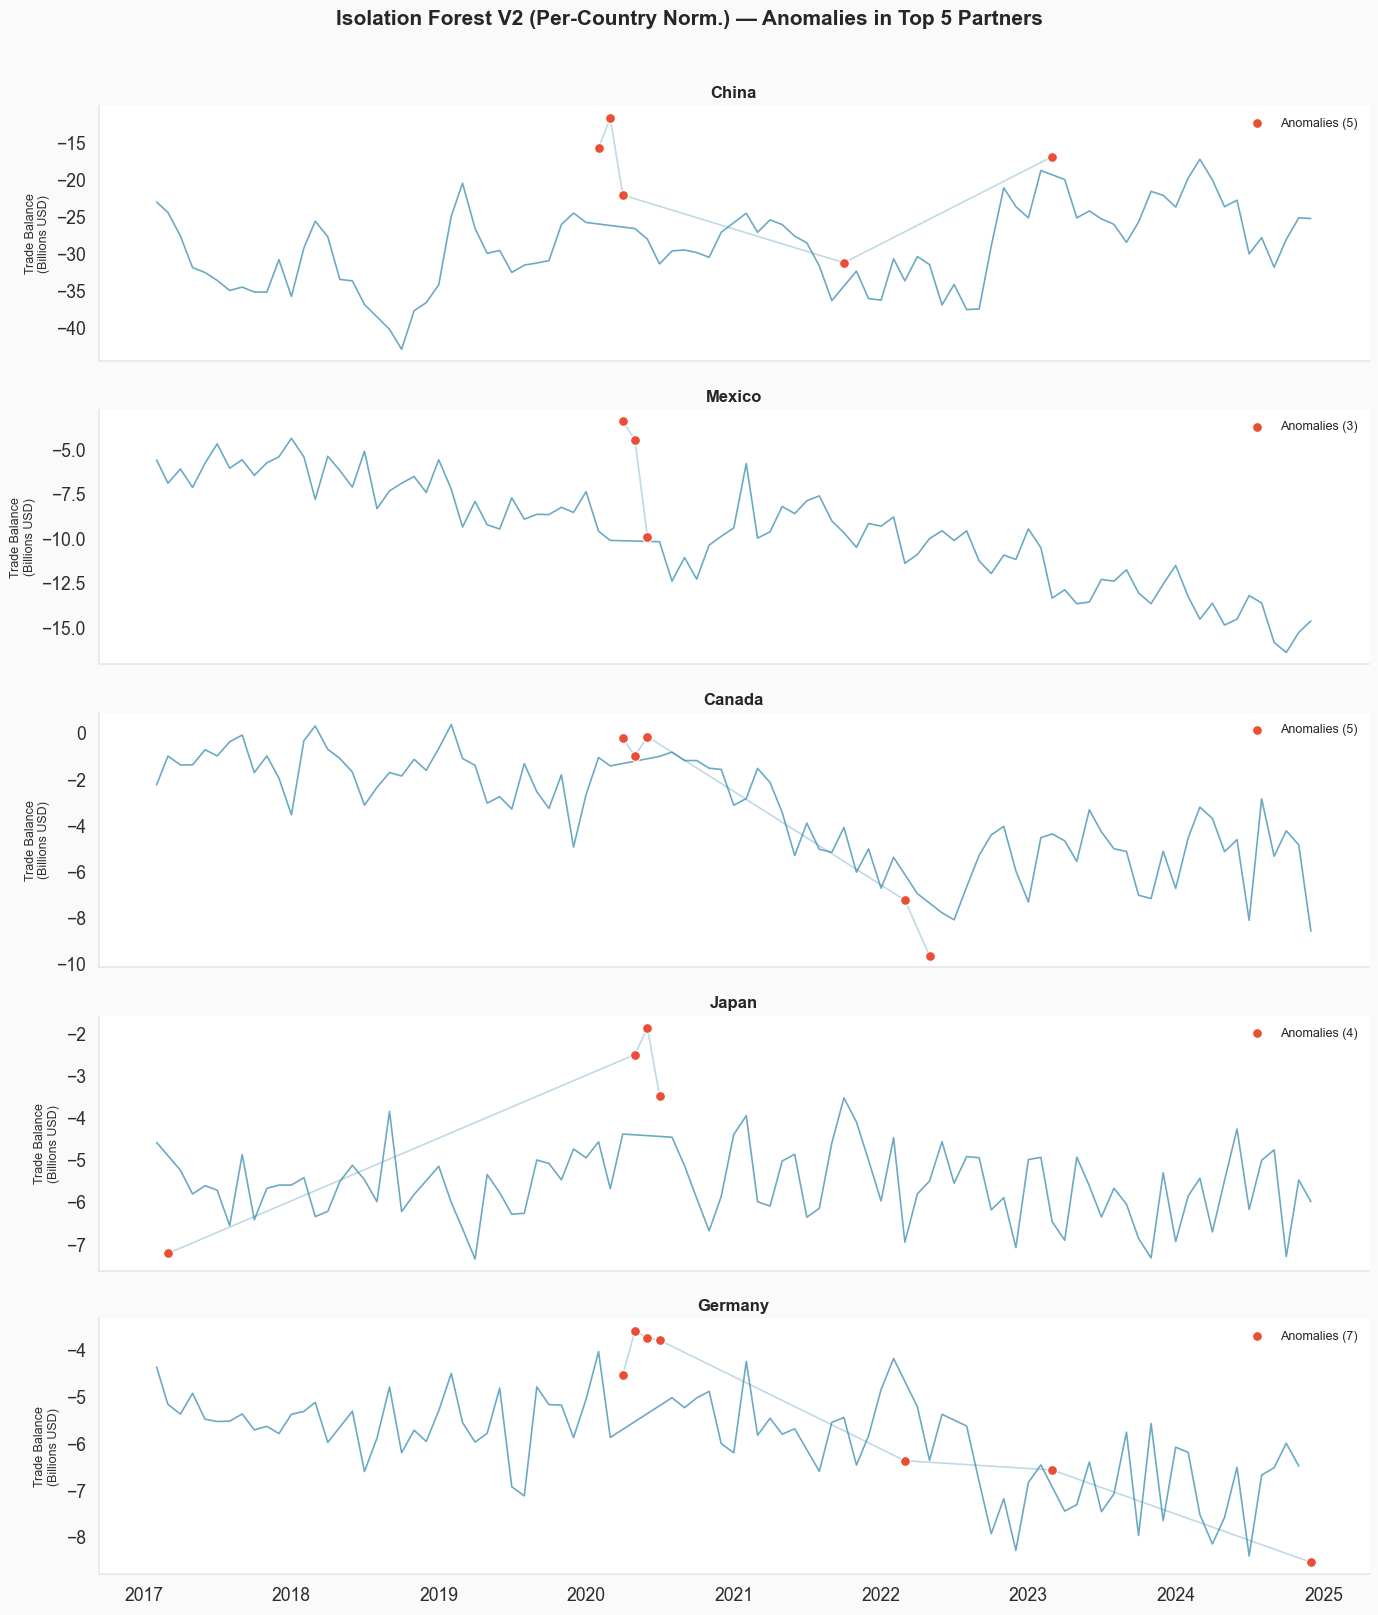

In [25]:
top5 = ["China", "Mexico", "Canada", "Japan", "Germany"]
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

for ax, country in zip(axes, top5):
    sub = df_v2[df_v2["country_display"] == country].sort_values("date")
    normal = sub[~sub["is_anomaly"]]
    anom = sub[sub["is_anomaly"]]

    ax.plot(normal["date"], normal["trade_balance"] / 1e9,
            color=COLORS["exports"], linewidth=1.2, alpha=0.7)
    ax.plot(anom["date"], anom["trade_balance"] / 1e9,
            color=COLORS["exports"], linewidth=1.2, alpha=0.3)
    ax.scatter(anom["date"], anom["trade_balance"] / 1e9,
               color=COLORS["imports"], s=50, zorder=5, edgecolors="white",
               linewidth=0.8, label=f"Anomalies ({len(anom)})")
    ax.set_ylabel("Trade Balance\n(Billions USD)", fontsize=9)
    ax.set_title(country, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Isolation Forest V2 (Per-Country Norm.) \u2014 Anomalies in Top 5 Partners",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [26]:
df_v2.to_csv(base / "data/final/anomaly_top30_results.csv", index=False)
print("Saved anomaly_top30_results.csv |", df_v2.shape)

Saved anomaly_top30_results.csv | (2850, 20)


## Trade Network Visualization (NetworkX)

This chart visualizes the US as a hub connected to all 30 trading partners. Edge thickness represents total bilateral trade volume. Red edges highlight countries where Isolation Forest V2 flagged more than 5% of months as anomalous.


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


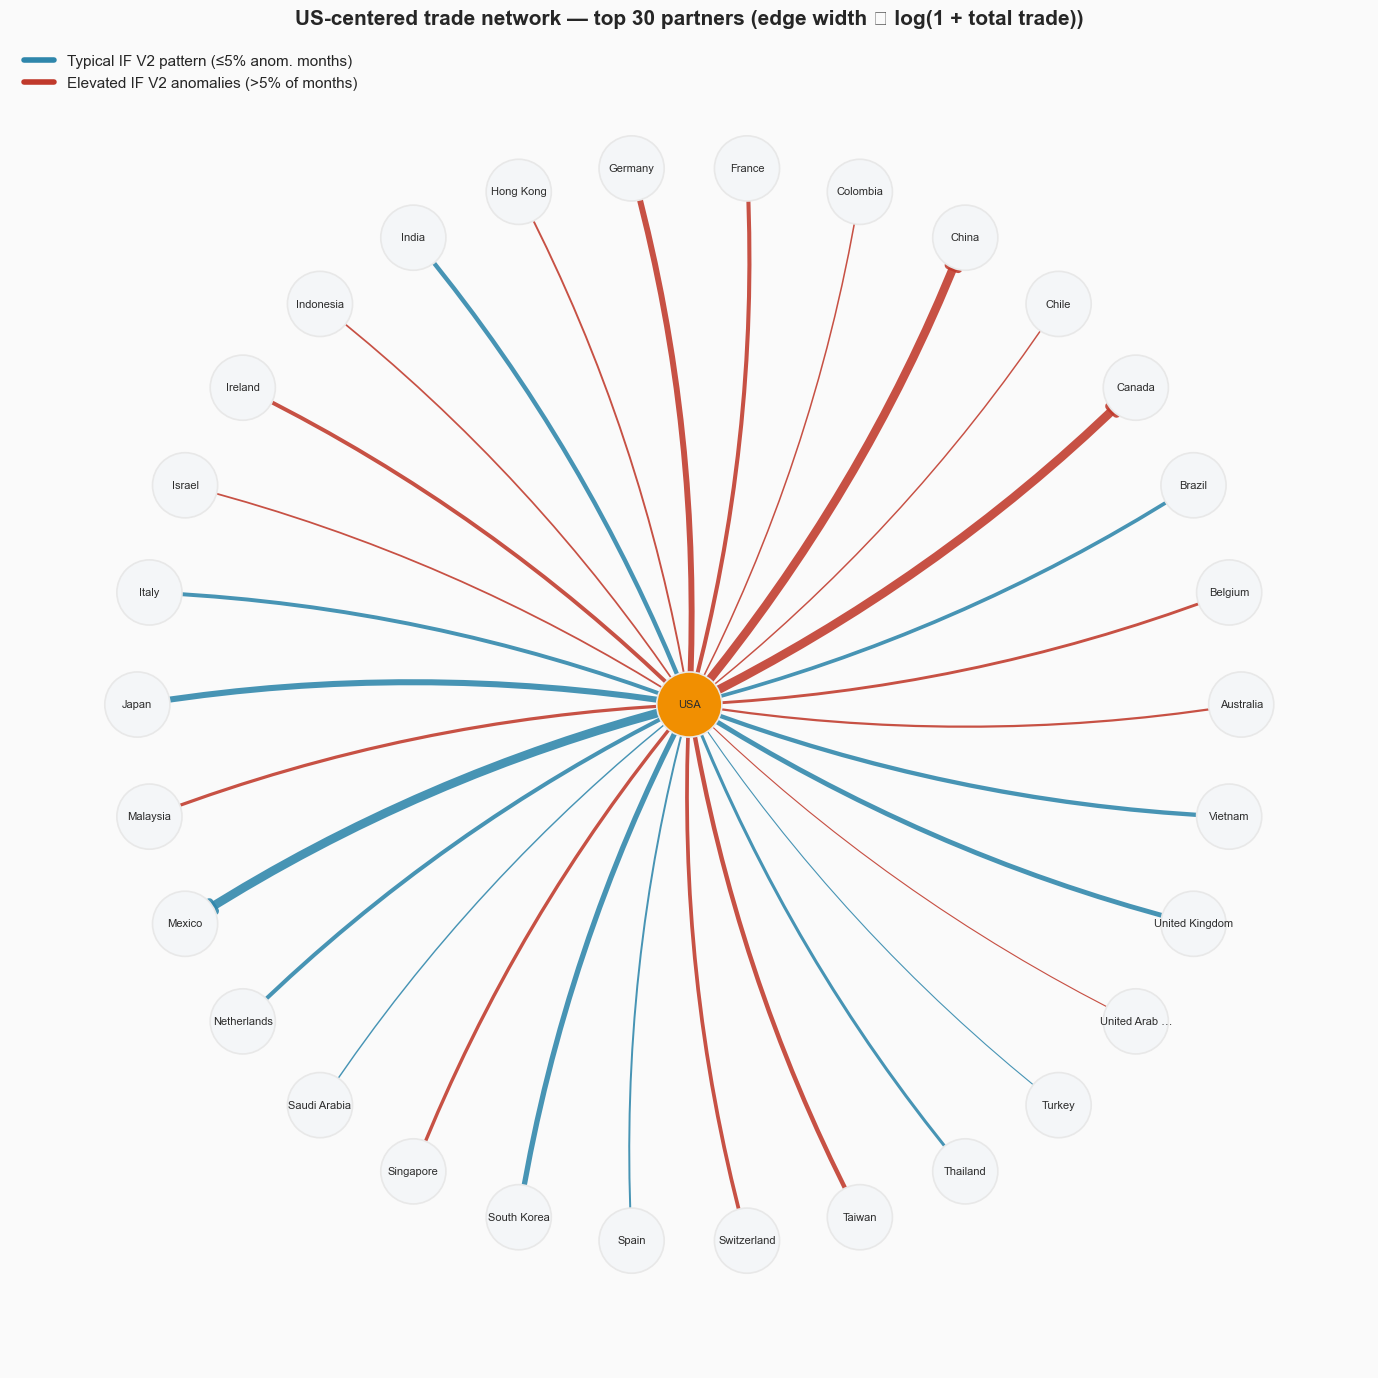

In [27]:
%pip install -q networkx
import networkx as nx

HUB = "United States"
flow = df_top30.groupby("country_display")["total_trade"].sum().reset_index(name="trade_flow")
anom = df_v2.groupby("country_display")["is_anomaly"].mean().reset_index(name="anomaly_rate")
partner_stats = flow.merge(anom, on="country_display", how="left").fillna({"anomaly_rate": 0.0})

G = nx.DiGraph()
G.add_node(HUB)
for _, row in partner_stats.iterrows():
    p = row["country_display"]
    G.add_node(p)
    w = float(np.log1p(max(row["trade_flow"], 1.0)))
    red = row["anomaly_rate"] > 0.05
    G.add_edge(HUB, p, weight=w, color=("#C0392B" if red else COLORS["exports"]), anom_rate=row["anomaly_rate"])

partners = partner_stats["country_display"].tolist()
n = len(partners)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
radius = 2.6
pos = {HUB: np.array([0.0, 0.0])}
for i, p in enumerate(partners):
    pos[p] = np.array([radius * np.cos(angles[i]), radius * np.sin(angles[i])])

wvals = np.array([d["weight"] for _, _, d in G.edges(data=True)])
wmin, wmax = wvals.min(), wvals.max()
norm_w = (wvals - wmin) / (wmax - wmin + 1e-9)

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_facecolor(COLORS["bg"])
for (u, v, d), nw in zip(G.edges(data=True), norm_w):
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], width=0.8 + 5.5 * nw,
        edge_color=[d["color"]], alpha=0.88, arrows=True, arrowsize=18,
        connectionstyle="arc3,rad=0.08", ax=ax,
    )

node_colors = [COLORS["accent1"] if n == HUB else "#F4F6F8" for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200, edgecolors=COLORS["grid"], linewidths=1.2, ax=ax)

short_labels = {HUB: "USA"}
for p in partners:
    short_labels[p] = p if len(p) <= 14 else p[:12] + "…"
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_color=COLORS["text"], ax=ax)

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color=COLORS["exports"], lw=4, label="Typical IF V2 pattern (≤5% anom. months)"),
    Line2D([0], [0], color="#C0392B", lw=4, label="Elevated IF V2 anomalies (>5% of months)"),
]
ax.legend(handles=legend_elems, loc="upper left", fontsize=11)
ax.set_title("US-centered trade network — top 30 partners (edge width ∝ log(1 + total trade))", fontsize=15, fontweight="bold", pad=12)
ax.axis("off")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
plt.tight_layout()
plt.show()
